In [1]:
import matplotlib.pyplot as plt

from script import run_superfv_sim, run_spd_sim
from superfv import RiemannSolver

In [2]:
def plot_fv(ax, sim):
    ax.set_aspect("equal")

    x_fv, y_fv, _ = sim.mesh.faces
    z_fv = sim.snapshot_history[-1].w[0, :, :, 0].T
    return ax.pcolormesh(x_fv, y_fv, z_fv)


def plot_sd(ax, sim):
    ax.set_aspect("equal")

    x_sd = sim.regular_faces()[0]
    y_sd = sim.regular_faces()[1]
    z_sd = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))[0]
    return ax.pcolormesh(x_sd, y_sd, z_sd)

In [5]:
sim1 = run_superfv_sim("llf", 3, 3200, rtol=1e-5, riemann_solver=RiemannSolver.LLF)
sim2 = run_superfv_sim("hllc", 3, 3200, rtol=1e-5, riemann_solver=RiemannSolver.HLLC)
sim3 = run_superfv_sim("llf", 7, 3200, rtol=1e-5, riemann_solver=RiemannSolver.LLF)
sim4 = run_superfv_sim("hllc", 7, 3200, rtol=1e-5, riemann_solver=RiemannSolver.HLLC)
sim5 = run_spd_sim("llf", 3, 3200, tolerance=1e-5, riemann_solver_sd="llf", riemann_solver_fv="llf")
sim6 = run_spd_sim("hllc", 3, 3200, tolerance=1e-5, riemann_solver_sd="hllc", riemann_solver_fv="hllc")
sim7 = run_spd_sim("llf", 7, 3200, tolerance=1e-5, riemann_solver_sd="llf", riemann_solver_fv="llf")
sim8 = run_spd_sim("hllc", 7, 3200, tolerance=1e-5, riemann_solver_sd="hllc", riemann_solver_fv="hllc")

Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_rtol=1e-1_NDOF=3200_p=3/params.pkl: Can't get attribute 'post_shock_state' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_rtol=1e-1_NDOF=3200_p=3'
Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_hllc_rtol=1e-1_NDOF=3200_p=3/params.pkl: Can't get attribute 'post_shock_state' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_hllc_rtol=1e-1_NDOF=3200_p=3'
Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_rtol=1e-1_NDOF=3200_p=7/params.pkl: Can't get attribute 'post_shock_state' on <module '__main__'>
Loaded output from '/scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_rtol=1e-1_NDOF=3200_p=7'
Error occurred while unpickling /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_hllc_rtol=1e-1_NDOF=3200_p=7/params.pkl

-> Loaded snapshot at t=0.2 from /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_rtol=1e-1_NDOF=3200_p=3/output_000001.pkl.
-> Loaded snapshot at t=0.2 from /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_hllc_rtol=1e-1_NDOF=3200_p=3/output_000001.pkl.
-> Loaded snapshot at t=0.2 from /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_llf_rtol=1e-1_NDOF=3200_p=7/output_000001.pkl.
-> Loaded snapshot at t=0.2 from /scratch/gpfs/jp7427/FVvsSD/double-mach-reflection/FV_hllc_rtol=1e-1_NDOF=3200_p=7/output_000001.pkl.


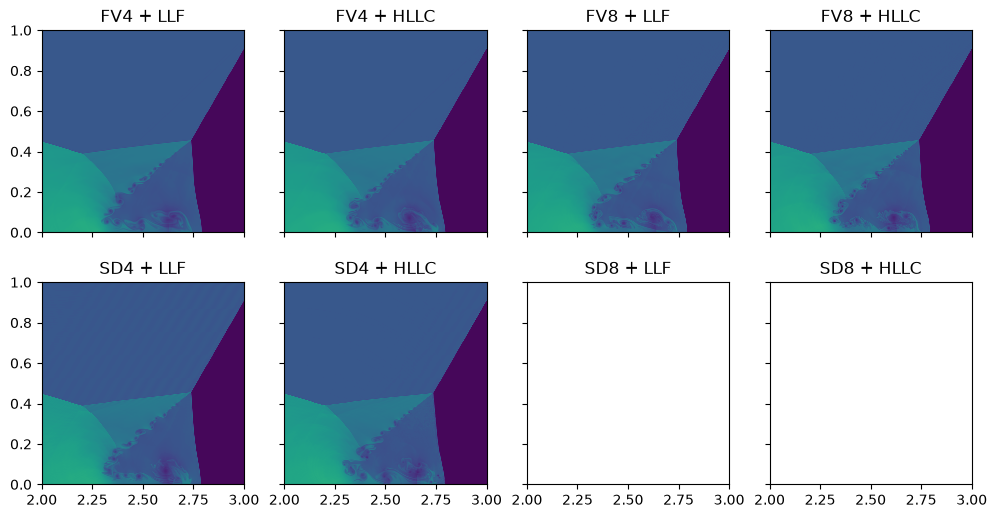

In [6]:
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(12, 6))
axs[0, 0].set_xlim(2, 3)

# plot_fv(axs[0], sim1)
# plot_fv(axs[1], sim2)

axs[0, 0].set_title("FV4 + LLF")
m0 = plot_fv(axs[0, 0], sim1)

axs[0, 1].set_title("FV4 + HLLC")
m1 = plot_fv(axs[0, 1], sim2)

axs[0, 2].set_title("FV8 + LLF")
m2 = plot_fv(axs[0, 2], sim3)

axs[0, 3].set_title("FV8 + HLLC")
m3 = plot_fv(axs[0, 3], sim4)

axs[1, 0].set_title("SD4 + LLF")
m4 = plot_sd(axs[1, 0], sim5)

axs[1, 1].set_title("SD4 + HLLC")
m5 = plot_sd(axs[1, 1], sim6)

axs[1, 2].set_title("SD8 + LLF")
m6 = plot_sd(axs[1, 2], sim7)

axs[1, 3].set_title("SD8 + HLLC")
m7 = plot_sd(axs[1, 3], sim8)

meshes = [m0, m1, m2, m3, m4, m5, m6, m7]
vmin = min(m.get_array().min() for m in meshes)
vmax = max(m.get_array().max() for m in meshes)
for m in meshes:
    m.set_clim(vmin, vmax)

fig.savefig("spd_dmr.png", dpi=300, bbox_inches="tight")